# Previsão do nível do Rio do Sinos em São Leopoldo
Dados oriundos de estação telemétrica  n° 87382000 no site Hidroweb - ANA

Feture: nivel do rio 

Target: nível do rio em horizontes futuros ( 2-48h )

Treinamento com dados de 2018 a junho de 2015 

Teste com dodos n=do mes de junho ( ocorrencia de anomalias de nivel)


1. Importação de bibliotecas necessárias para todo o projeto


bibliotecas necessárias: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn ,tensorflow, openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


2. Carregamento dos dados.
   
O dataset é oriundo da estação cujo código de idenficação é 87382000.Possui as colunas data, hora, chuva, nível e vazão.

Vamos selecionar apenas a coluda data e hora ( fundir em uma unica 'datetime') e a coluna 'Nivel(cm)'.

Finalmente converter dados para número, forçando erros para NaN
 

In [2]:
# Caminho completo
caminho = r"C:\Users\AdmPDI\Documents\Doutorado\Dados\Projeto_1\87382000-SAO LEOPOLDO.xlsx"

# Leitura do Excel
df = pd.read_excel(caminho, engine="openpyxl")

# Exibe as primeiras linhas
print(df.head())


        Data      Hora     Chuva (mm) Nível (cm)  Vazão (m3/s)
0 2018-08-01  13:15:00                       358         174.7
1 2018-08-01  13:30:00              0        358         174.7
2 2018-08-01  13:45:00              0        357         174.0
3 2018-08-01  14:00:00              0        357         174.0
4 2018-08-01  14:15:00              0        357         174.0


In [3]:

# Combinação das colunas 'Data' e 'Hora' em uma única coluna datetime
df['datetime'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Hora'].astype(str), errors='coerce')

#  Seleção das colunas relevantes e conversão para numérico
df1 = df[['datetime', 'Nível (cm)']].copy()
df1['Nível (cm)'] = pd.to_numeric(df1['Nível (cm)'], errors='coerce')

# Criação da série temporal com cópia para processamento
serie = df1.set_index('datetime')[['Nível (cm)']].copy()

# Preenchimento de valores faltantes via interpolação e preenchimento alternativo
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_31732\715588396.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237414 entries, 0 to 237413
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    237414 non-null  datetime64[ns]
 1   Nível (cm)  230408 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.6 MB
None
             datetime  Nível (cm)
0 2018-08-01 13:15:00       358.0
1 2018-08-01 13:30:00       358.0
2 2018-08-01 13:45:00       357.0
3 2018-08-01 14:00:00       357.0
4 2018-08-01 14:15:00       357.0


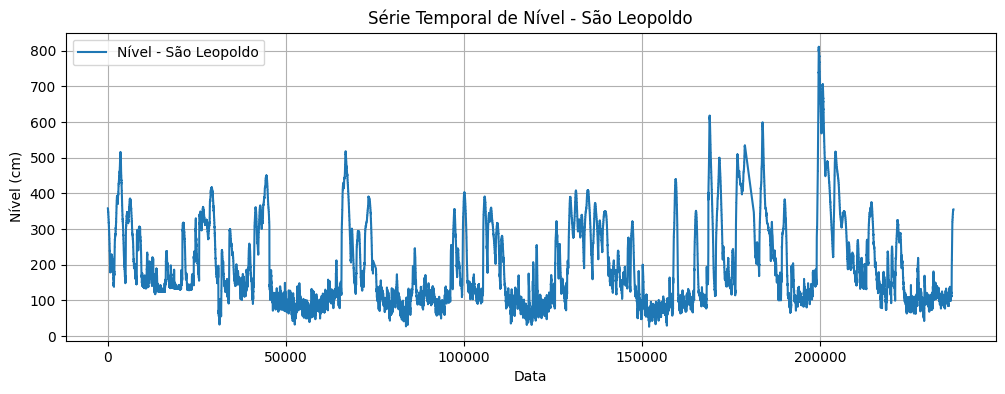

In [4]:
print(df1.info())
print(df1.head())

# 4. Plotar a série temporal de vazão
plt.figure(figsize=(12, 4))
plt.plot(df1.index, serie['Nível (cm)'], label='Nível - São Leopoldo')
plt.title('Série Temporal de Nível - São Leopoldo')
plt.xlabel('Data')
plt.ylabel("Nível (cm)")
plt.grid(True)
plt.legend()
plt.show()


# Treinar o modelo com todos os dados com previsão de 2,4,8,12,24 e 48 horas de antecedência. 



In [4]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import save_model

# 📂 Pré-processamento da série
serie = df1[['Nível (cm)']].copy()
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].ffill().bfill()

# Configurações
janela = 10
atrasos = [8, 16, 32, 48, 96,192]  # Correspondem a 120min, 240min, ..., 2880min

def cria_janelas(series, janela=10, atraso=8):
    X, y = [], []
    for i in range(len(series) - janela - atraso):
        X.append(series[i:i+janela])
        y.append(series[i+janela+atraso-1])
    return np.array(X), np.array(y)

# Loop de treino com 100% dos dados
for atraso in atrasos:
    minutos = atraso * 15
    nome_base = f"{minutos}min"  # Ex: 120min, 240min, etc.
    
    print(f"\n🚀 Treinando modelo FINAL para {minutos} minutos (≈ {minutos//60}h)...")
    
    # Geração das janelas
    X_raw, y_raw = cria_janelas(serie.values, janela, atraso)

    # Normalização total
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw.reshape(-1, 1)).reshape(X_raw.shape)
    y_scaled = scaler.transform(y_raw.reshape(-1, 1))

    # Modelo LSTM
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(janela, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_scaled, y_scaled, epochs=30, batch_size=32, verbose=1)

    # Caminhos únicos para cada modelo e scaler
    modelo_path = f"modelo_previsao_{nome_base}.h5"
    scaler_path = f"scaler_previsao_{nome_base}.save"

    # Salvamento
    model.save(modelo_path)
    joblib.dump(scaler, scaler_path)

    print(f"✅ Modelo salvo como: {modelo_path}")
    print(f"✅ Scaler salvo como: {scaler_path}")



🚀 Treinando modelo FINAL para 120 minutos (≈ 2h)...
Epoch 1/30


c:\Users\AdmPDI\Documents\Conda3\envs\riosinos\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7419/7419 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 1.2189e-04
Epoch 2/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 3.1452e-05
Epoch 3/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.8609e-05
Epoch 4/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.6610e-05
Epoch 5/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.5884e-05
Epoch 6/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.5552e-05
Epoch 7/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.5393e-05
Epoch 8/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.5131e-05
Epoch 9/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.5246e-05
Epoch 10/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.4877e-05
Epoch 11/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.4936e-05
Epoch 12/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.4843e-05
Epoch 13/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 2.4737e-05
Epoch 14/30
7419/7419 ━━━━━━━━━━━━━━━━━━━━ 16

✅ Modelo salvo como: modelo_previsao_120min.h5
✅ Scaler salvo como: scaler_previsao_120min.save

🚀 Treinando modelo FINAL para 240 minutos (≈ 4h)...
Epoch 1/30


c:\Users\AdmPDI\Documents\Conda3\envs\riosinos\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

7416/7416 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.0012
Epoch 2/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0011
Epoch 3/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0010
Epoch 4/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0010
Epoch 5/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.8388e-04
Epoch 6/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.6472e-04
Epoch 7/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.5119e-04
Epoch 8/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.4564e-04
Epoch 9/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.4125e-04
Epoch 10/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 9.3257e-04
Epoch 11/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.2741e-04
Epoch 12/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.2244e-04
Epoch 13/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 9.1868e-04
Epoch 14/30
7416/7416 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - los

✅ Modelo salvo como: modelo_previsao_1440min.h5
✅ Scaler salvo como: scaler_previsao_1440min.save

🚀 Treinando modelo FINAL para 2880 minutos (≈ 48h)...
Epoch 1/30


c:\Users\AdmPDI\Documents\Conda3\envs\riosinos\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7413/7413 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0029
Epoch 2/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.0028
Epoch 3/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0028
Epoch 4/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0027
Epoch 5/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0027
Epoch 6/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0026
Epoch 7/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0026
Epoch 8/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0026
Epoch 9/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0026
Epoch 10/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0025
Epoch 11/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0025
Epoch 12/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0025
Epoch 13/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0025
Epoch 14/30
7413/7413 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0025
Epoch 15/30
7413/7413 ━━━━

✅ Modelo salvo como: modelo_previsao_2880min.h5
✅ Scaler salvo como: scaler_previsao_2880min.save
